In [26]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

In [27]:
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']
#regions = ['M1R', 'M1L']

cst_wm = pd.read_csv(os.path.join(gl.baseDir, 'lme', 'results_fe_re', 'patients_MNISymC_WM_mod_CST_lme.tsv'), sep = '\t')
cerebel_gm = pd.read_csv(os.path.join(gl.baseDir, 'lme', 'results_fe_re', 'patients_MNISymC_GM_mod_Nettekoven_2024_lme.tsv'), sep = '\t')

cerebel_gm = cerebel_gm[cerebel_gm.regionname.isin(regions)]

cst_wm['hemisphere'] = cst_wm.regionname.str[0].astype(str).str.upper()
cerebel_gm['hemisphere'] = cerebel_gm.regionname.str[2]


# for intercept, mean = beta + random_intercept; for all others, mean = beta
cst_wm['mean'] = cst_wm.apply(lambda x: x['beta'] + x['random_intercept'] if x['Week'] == 0 else x['beta'], axis = 1)
cerebel_gm['mean'] = cerebel_gm.apply(lambda x: x['beta'] + x['random_intercept'] if x['Week'] == 0 else x['beta'], axis = 1)

In [ ]:
cst_week = 0
cerebel_week = 0

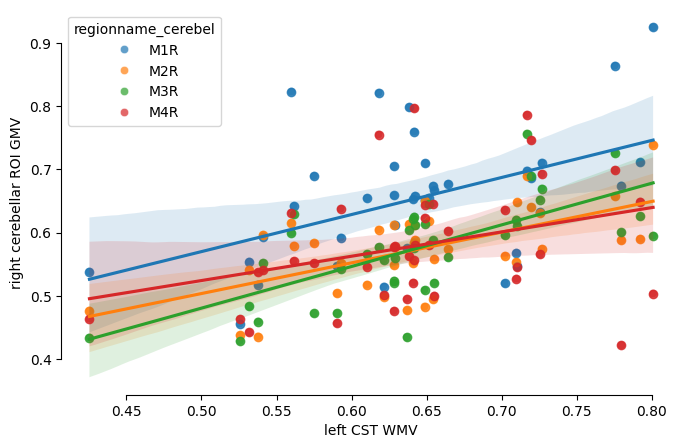

In [29]:
left_cst = cst_wm[(cst_wm.hemisphere == 'L')&(cst_wm.Week == cst_week)] # contralesional CST
right_cerebel = cerebel_gm[(cerebel_gm.hemisphere == 'R') & (cerebel_gm.Week == cerebel_week)] # ipsilesional cerebellum
left_df = pd.merge(left_cst, right_cerebel, on = ['subj_id'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (8,5))
sns.scatterplot(x = left_df['mean_cst'], y=left_df['mean_cerebel'], hue = left_df['regionname_cerebel'], alpha = .7, ax = ax)
for region in left_df['regionname_cerebel'].unique():
    sns.regplot(data = left_df[left_df['regionname_cerebel'] == region], x = 'mean_cst', y = 'mean_cerebel',  ax = ax)

plt.xlabel("left CST WMV")
plt.ylabel("right cerebellar ROI GMV")

sns.despine(trim = True)
plt.show()

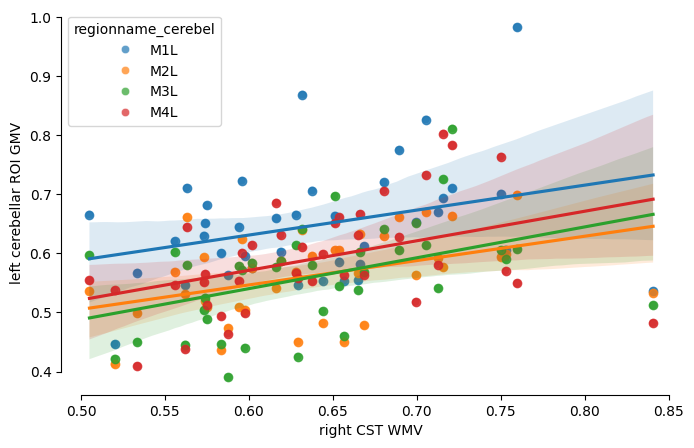

In [30]:
right_cst = cst_wm[(cst_wm.hemisphere == 'R')&(cst_wm.Week == cst_week)] # ipsilesional CST
left_cerebel = cerebel_gm[(cerebel_gm.hemisphere == 'L') & (cerebel_gm.Week == cerebel_week)] # contralesional cerebellum
right_df = pd.merge(right_cst, left_cerebel, on = ['subj_id'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (8,5))
sns.scatterplot(x = right_df['mean_cst'], y=right_df['mean_cerebel'], hue = right_df['regionname_cerebel'], alpha = .7, ax = ax)
for region in right_df['regionname_cerebel'].unique():
    sns.regplot(data = right_df[right_df['regionname_cerebel'] == region], x = 'mean_cst', y = 'mean_cerebel',  ax = ax)

plt.xlabel("right CST WMV")
plt.ylabel("left cerebellar ROI GMV")

sns.despine(trim = True)
plt.show()